# 5.5 Les données à grande échelle : lire depuis un stockage objet dans le cloud

Tous les jeux de données de ce livre tenaient jusqu'ici en mémoire. Ce carnet travaille sur un jeu qui n'y tient pas : l'analyse [MUR SST](https://registry.opendata.aws/mur/) — température quotidienne de surface de la mer, mondiale, à 0,01° (~1 km) de résolution, 2002–2020, publiée sous forme de magasin Zarr sur le registre AWS Open Data (`s3://mur-sst/zarr-v1`, `region` `us-west-2`, accès anonyme). Une fois décodé, le magasin décrit environ **106 Tio** de tableaux. Nous allons l'ouvrir, en extraire un sous-ensemble et calculer dessus depuis un portable, en gardant une question au premier plan : **combien d'octets se déplacent réellement ?**

C'est la version exécutable du motif « lire sur place » de la [section 5.4](5.4_compute_beyond_laptop.md).

**Crédit des données :** JPL MUR MEaSUREs Project (2015), *GHRSST Level 4 MUR Global Foundation Sea Surface Temperature Analysis v4.1*, NASA PO.DAAC, [doi:10.5067/GHGMR-4FJ04](https://doi.org/10.5067/GHGMR-4FJ04) ; Chin, Vazquez-Cuervo & Armstrong (2017), *Remote Sensing of Environment* 200.

```{note}
Les sorties de cette page ont été enregistrées lors d'une exécution réelle contre le magasin public (les commandes sont exactement celles qui sont montrées, et vous pouvez réexécuter chaque cellule vous-même). La construction automatisée du livre rend ces sorties enregistrées au lieu de réexécuter le carnet, si bien que la fabrication des pages ne dépend pas d'un accès réseau à AWS.
```


🖥️ [**Diapositives du cours — Séance 27 (ven. 4 déc.)**](https://geo-smart.github.io/mlgeo-book/slides/2026/lec27_ship_it_honestly.html)

## Atteindre le magasin — et échouer vite si vous n'y arrivez pas

Un petit objet, `.zmetadata`, contient les *métadonnées consolidées* du magasin : forme, dtype, découpage en blocs (*chunks*) et compression de chaque tableau, en une seule lecture d'environ 10 Kio. Nous le vérifions d'abord avec des délais d'attente courts, pour qu'un réseau bloqué produise une erreur claire en quelques secondes au lieu d'un blocage silencieux de plusieurs minutes.

In [1]:
import time

import numpy as np
import s3fs
import xarray as xr

STORE = "mur-sst/zarr-v1"
S3_OPTS = {
    "anon": True,  # public bucket, no credentials
    "config_kwargs": {"connect_timeout": 10, "read_timeout": 30, "retries": {"max_attempts": 2}},
}

fs = s3fs.S3FileSystem(**S3_OPTS)
try:
    meta = fs.info(f"{STORE}/.zmetadata")
except Exception as err:
    raise RuntimeError(
        f"Cannot reach s3://{STORE} (anonymous, region us-west-2). "
        "Check your connection. On restricted networks, outbound anonymous S3 is often "
        "blocked entirely -- see the admonition at the end of this notebook and the "
        "'Restricted environments' section of 5.4."
    ) from err


def fmt(nbytes):
    """Human-readable byte count."""
    for unit in ["B", "KiB", "MiB", "GiB", "TiB", "PiB"]:
        if nbytes < 1024:
            return f"{nbytes:,.1f} {unit}"
        nbytes /= 1024


print(f"store reachable; consolidated metadata: {fmt(meta['size'])} -- one GET describes everything below")

store reachable; consolidated metadata: 10.3 KiB -- one GET describes everything below


## Ouvrir 106 Tio paresseusement

`xr.open_dataset(..., engine="zarr", chunks={})` ne lit que cet objet de métadonnées. `chunks={}` signifie « donne-moi un tableau dask dont les blocs correspondent aux blocs sur disque » — aucune valeur de données ne traverse le réseau avant que nous ne la demandions.

In [2]:
t0 = time.time()
ds = xr.open_dataset(
    f"s3://{STORE}",
    engine="zarr",
    chunks={},  # lazy: dask chunks = storage chunks
    backend_kwargs={"storage_options": S3_OPTS},
)
print(f"opened in {time.time() - t0:.1f} s: {fmt(ds.nbytes)} of arrays described, ~{fmt(meta['size'])} actually read")
ds

opened in 12.9 s: 106.3 TiB of arrays described, ~10.3 KiB actually read


<xarray.Dataset> Size: 117TB
Dimensions:           (time: 6443, lat: 17999, lon: 36000)
Coordinates:
  * time              (time) datetime64[ns] 52kB 2002-06-01T09:00:00 ... 2020...
  * lat               (lat) float32 72kB -89.99 -89.98 -89.97 ... 89.98 89.99
  * lon               (lon) float32 144kB -180.0 -180.0 -180.0 ... 180.0 180.0
Data variables:
    analysed_sst      (time, lat, lon) float64 33TB dask.array<chunksize=(5, 1799, 3600), meta=np.ndarray>
    analysis_error    (time, lat, lon) float64 33TB dask.array<chunksize=(5, 1799, 3600), meta=np.ndarray>
    mask              (time, lat, lon) float32 17TB dask.array<chunksize=(5, 1799, 3600), meta=np.ndarray>
    sea_ice_fraction  (time, lat, lon) float64 33TB dask.array<chunksize=(5, 1799, 3600), meta=np.ndarray>
Attributes: (12/47)
    Conventions:                CF-1.7
    Metadata_Conventions:       Unidata Observation Dataset v1.0
    acknowledgment:             Please acknowledge the use of these data with...
    cdm_data_type:              grid
    comment:                    MUR = "Multi-scale Ultra-high Resolution"
    creator_email:              ghrsst@podaac.jpl.nasa.gov
    ...                         ...
    summary:                    A merged, multi-sensor L4 Foundation SST anal...
    time_coverage_end:          20200116T210000Z
    time_coverage_start:        20200115T210000Z
    title:                      Daily MUR SST, Final product
    uuid:                       27665bc0-d5fc-11e1-9b23-0800200c9a66
    westernmost_longitude:      -180.0

## Les blocs : l'unité de tout

Un **bloc** (*chunk*) est l'unité atomique d'entrée-sortie et de compression du magasin : chaque lecture récupère et décompresse des blocs entiers, jamais des valeurs isolées, si bien que votre schéma d'accès se paie en pièces de la taille d'un bloc. Zarr v3 ajoute les **fragments** (*shards*) — de nombreux petits blocs empaquetés dans un même objet de stockage, pour qu'un stockage objet ne soit pas noyé sous des millions de fichiers minuscules ; ce magasin leur est antérieur (agencement Zarr v2), donc chaque bloc *est* un objet S3 et l'unité de transfert réseau.

`analysed_sst` est stocké en `int16` (un couple échelle/décalage reconstitue les kelvins) en blocs de 5 jours × 1799 lat × 3600 lon. Pesons-en un.

In [3]:
sst = ds["analysed_sst"]
storage_chunks = sst.encoding["chunks"]
chunk_of = dict(zip(sst.dims, storage_chunks))
print("shape:", sst.shape, "-> storage chunks:", storage_chunks)
print("stored dtype:", sst.encoding["dtype"], "| decoded dtype:", sst.dtype)

nchunks = tuple(int(np.ceil(s / c)) for s, c in zip(sst.shape, storage_chunks))
print("chunk grid:", nchunks, "=", f"{int(np.prod(nchunks)):,}", "chunk objects for this variable")

one = fs.info(f"{STORE}/analysed_sst/1200.7.1")  # one arbitrary chunk object
decoded_chunk = int(np.prod(storage_chunks)) * sst.dtype.itemsize
print(f"one chunk: {fmt(one['size'])} compressed on S3 -> {fmt(decoded_chunk)} decoded in RAM")
print(f"variable:  ~{fmt(one['size'] * np.prod(nchunks))} compressed (est. from that chunk) -> {fmt(sst.nbytes)} decoded")

# Rechunk on read: dask chunks must be multiples of the storage chunks, or every
# dask task re-reads partial storage chunks. This merges pairs of 5-day chunks:
sst10 = sst.chunk({"time": 10})  # equivalently: chunks={"time": 10, ...} in open_dataset
print("dask chunks after rechunk-on-read:", sst10.data.chunksize)

shape: (6443, 17999, 36000) -> storage chunks: (5, 1799, 3600)
stored dtype: int16 | decoded dtype: float64
chunk grid: (1289, 11, 10) = 141,790 chunk objects for this variable
one chunk: 20.0 MiB compressed on S3 -> 247.1 MiB decoded in RAM
variable:  ~2.7 TiB compressed (est. from that chunk) -> 30.4 TiB decoded


dask chunks after rechunk-on-read: (10, 1799, 3600)


## Sous-échantillonner paresseusement, puis calculer

Dix jours au-dessus du plateau continental du Pacifique Nord-Ouest : 46–49°N, 126–122°O, juin 2019. Découper un tableau paresseux modifie le graphe de tâches — cela déplace toujours **zéro** octet.

In [4]:
TIME = slice("2019-06-01", "2019-06-10")
LAT, LON = slice(46, 49), slice(-126, -122)

sub = sst.sel(time=TIME, lat=LAT, lon=LON)
print(f"subset {sub.shape}: {fmt(sub.data.nbytes)} across {sub.data.npartitions} chunks -- 0 bytes moved so far")

subset (10, 301, 401): 9.2 MiB across 3 chunks -- 0 bytes moved so far


`.compute()` est le moment où la facture réseau arrive. Deux décomptes d'octets différents comptent, et nous mesurons les deux :

- **octets en RAM** — le `nbytes` de dask sur le résultat calculé : ce que votre réponse coûte en mémoire ;
- **octets déplacés** — le réseau transfère des objets-blocs compressés entiers, donc nous énumérons exactement quels objets-blocs le sous-ensemble touche et nous sommons leurs tailles sur S3.

In [5]:
t0 = time.time()
box = sub.compute()
elapsed = time.time() - t0

# Which chunk objects did that read touch? Convert the label slices to integer
# index ranges, divide by the chunk size along each dimension, and list the keys.
ranges = {}
for dim, sel in {"time": TIME, "lat": LAT, "lon": LON}.items():
    start, stop = sst.get_index(dim).slice_locs(sel.start, sel.stop)
    ranges[dim] = range(start // chunk_of[dim], (stop - 1) // chunk_of[dim] + 1)
keys = [
    f"{STORE}/analysed_sst/{t}.{y}.{x}"
    for t in ranges["time"] for y in ranges["lat"] for x in ranges["lon"]
]
moved = sum(fs.info(k)["size"] for k in keys)

print(f"chunk objects fetched : {len(keys)} (= {sub.data.npartitions} graph partitions)")
print(f"bytes moved           : {fmt(moved)} compressed, in {elapsed:.1f} s")
print(f"bytes in RAM (result) : {fmt(box.nbytes)}")
print(f"bytes stored (decoded): {fmt(sst.nbytes)}")
print(f"moved : stored        = 1 : {sst.nbytes / moved:,.0f}")
print(f"mean SST in the box   : {float(box.mean()):.2f} K")

chunk objects fetched : 3 (= 3 graph partitions)
bytes moved           : 60.6 MiB compressed, in 20.4 s
bytes in RAM (result) : 9.2 MiB
bytes stored (decoded): 30.4 TiB
moved : stored        = 1 : 525,483
mean SST in the box   : 285.94 K


Ce rapport est tout l'argument en faveur des formats optimisés pour le cloud. Le magasin contient 30,4 Tio (décodés) d'`analysed_sst` ; répondre à notre question a déplacé 60,6 Mio — **une part sur ~525 000** — parce que le découpage en blocs rend les lectures partielles peu coûteuses et que la paresse fait que nous n'avons jamais demandé que les blocs touchés par notre découpe. Les 60,6 Mio font aussi ~6 fois plus que les 9,2 Mio arrivés en RAM : la granularité des blocs est la taxe que vous payez pour le stockage objet, et la raison pour laquelle la forme des blocs devrait correspondre à peu près à votre schéma d'accès.

## Le moment où le tout-en-mémoire meurt

Faites le calcul avant d'appeler `.compute()` sur quoi que ce soit de gros. Un seul pas de temps mondial d'`analysed_sst` se décode en 17 999 × 36 000 × 8 octets ≈ **4,8 Gio**. Trois jours épuisent un portable de 16 Gio. La variable complète fait 30,4 Tio — environ deux mille portables de RAM — et `sst.values` (ou `.compute()` sur le tableau non découpé) tenterait allègrement de la matérialiser. Nous n'allons pas exécuter cela, et vous non plus : le remède n'est jamais un `.compute()` plus gros, c'est un algorithme qui ne garde que quelques blocs à la fois.

## En flux : l'agrégation qui réussit

Une moyenne mensuelle sur la même boîte demande 30 journées mondiales — ~145 Gio décodés si vous chargiez des pas de temps entiers, mais toujours seulement 7 objets-blocs pour notre découpe. `mean("time")` sur le tableau paresseux construit un graphe de *moyennes partielles par bloc* que dask combine : chaque travailleur récupère un objet-bloc de 20 Mio, le décompresse (62 Mio d'`int16`, 247 Mio une fois décodés en `float64`), en prend la moyenne partielle sur la découpe, puis le jette. La mémoire de pointe reste à une poignée de blocs, quelle que soit la longueur de l'axe temporel.

In [6]:
june = sst.sel(time=slice("2019-06-01", "2019-06-30"), lat=LAT, lon=LON)
june_mean = june.mean("time")  # lazy: per-chunk partial means, combined at the end

print(f"graph input : {fmt(june.data.nbytes)} across {june.data.npartitions} chunks")
print(f"graph output: {fmt(june_mean.data.nbytes)}")

t0 = time.time()
june_map = june_mean.compute()
print(f"streamed in {time.time() - t0:.1f} s; peak memory ~ a few chunks, not {fmt(sst.nbytes)}")

graph input : 27.6 MiB across 7 chunks
graph output: 943.0 KiB


streamed in 40.8 s; peak memory ~ a few chunks, not 30.4 TiB


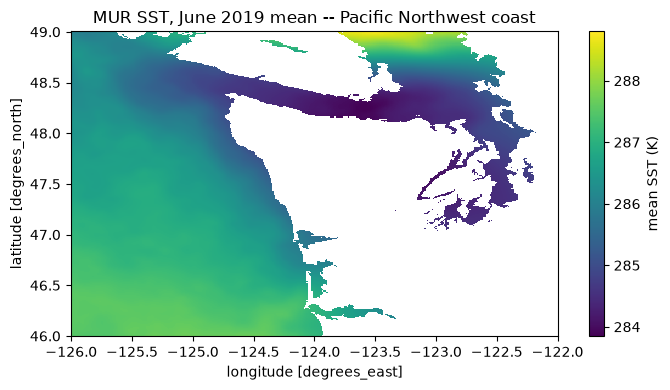

In [7]:
import matplotlib.pyplot as plt

june_map.plot(figsize=(7, 4), cmap="viridis", cbar_kwargs={"label": "mean SST (K)"})
plt.title("MUR SST, June 2019 mean -- Pacific Northwest coast")
plt.tight_layout()
plt.show()

```{admonition} Les lectures S3 anonymes échouent sur les réseaux restreints
:class: warning
Sur beaucoup de réseaux institutionnels — laboratoires nationaux, enclaves d'agences, certains nœuds de calcul HPC de campus — l'accès S3 anonyme sortant est bloqué. Le symptôme est rarement une erreur propre : l'ouverture reste bloquée toute la durée du délai d'attente, puis lève un `ConnectTimeoutError`/`EndpointConnectionError`, ou bien un mandataire répond par un `403` trompeur. (La première cellule de ce carnet emploie des délais de 10 secondes et un message d'erreur en langage clair précisément pour que l'échec soit rapide et lisible.) Le repli n'est pas de se battre contre le pare-feu : utilisez un miroir institutionnel de l'archive s'il en existe un, ou **pré-acheminez un sous-ensemble** — exécutez les cellules de sous-échantillonnage sur une machine connectée, faites `box.to_netcdf(...)` du résultat (9,2 Mio, pas 30,4 Tio), faites-le passer par votre passerelle de transfert homologuée, et épinglez son empreinte avec pooch ([section 1.6](../Chapter1-GettingStarted/1.6_data_gallery.md)). Le versant environnement du même problème est traité en [5.4, « Environnements restreints »](5.4_compute_beyond_laptop.md).
```

## Portable → HPC → cloud : la décision en chiffres

Ce carnet a répondu à des questions sur une variable de 30,4 Tio en déplaçant ~200 Mio au total — largement un travail de portable, parce que les blocs que nous avons touchés tenaient dans notre bande passante et notre RAM. C'est la règle générale :

- **Blocs touchés ≪ votre RAM et votre patience** → portable, exactement comme ici. Ouverture paresseuse, sous-échantillonnage, flux.
- **Blocs touchés ≈ le magasin entier** (une climatologie mondiale sur toute la série ; un entraînement de ML sur tous les blocs) → déplacez le calcul vers les données, et non les données vers le calcul : une instance dans `us-west-2` lit ce *bucket* à plusieurs Go/s sans frais de sortie, et une grappe HPC convient quand les données (ou un miroir) sont déjà sur son système de fichiers.
- Dans les deux cas, la requête voyage vers les données et seules les réponses reviennent — le motif « lire sur place » de la [section 5.4](5.4_compute_beyond_laptop.md), qui couvre aussi l'échelle de calcul elle-même : grappe de laboratoire ou mésocentre, GENCI/eDARI et NSF ACCESS, cloud commercial, et la discipline des coûts qui rend le dernier survivable.